In [10]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.metrics import accuracy_score

# 1. Load data, skipping the first 7 rows of metadata in your CSV
# Change pd.read_csv to pd.read_excel
df = pd.read_excel('Palay-Raw-Datasets.xlsx', skiprows=7)
df.columns = ['Trial', 'Category', 'Arduino_Value']

# 2. Clean the Data
# Make categories consistent (e.g., 'Overdry' to 'over dry')
df['Category'] = df['Category'].str.strip().str.lower()
df['Category'] = df['Category'].replace({'overdry': 'over dry'})

# Remove 'ADC' string from values and convert to integer
df['Arduino_Value'] = df['Arduino_Value'].astype(str).str.replace('ADC', '', case=False).str.strip()
df['Arduino_Value'] = pd.to_numeric(df['Arduino_Value'], errors='coerce')
df = df.dropna()

# 3. Define Features (X) and Target (y)
X = df[['Arduino_Value']]
y = df['Category']

# 4. Split into Training and Testing datasets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Train the Decision Tree Model
clf = DecisionTreeClassifier(max_depth=2, random_state=42)
clf.fit(X_train, y_train)

# 6. Evaluate
y_pred = clf.predict(X_test)
print(f'Model Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%\n')

# 7. Extract the Logic to embed in Arduino
tree_rules = export_text(clf, feature_names=['Arduino_Value'])
print("Extracted Arduino Rules:")
print(tree_rules)

Model Accuracy: 100.00%

Extracted Arduino Rules:
|--- Arduino_Value <= 238.50
|   |--- class: over dry
|--- Arduino_Value >  238.50
|   |--- Arduino_Value <= 621.50
|   |   |--- class: dry
|   |--- Arduino_Value >  621.50
|   |   |--- class: wet



==== PERFORMANCE METRICS ====
Accuracy: 100.00%

              precision    recall  f1-score   support

         dry       1.00      1.00      1.00         9
    over dry       1.00      1.00      1.00        10
         wet       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30


==== LOGISTIC REGRESSION EQUATION PARAMETERS ====
Classes Output Order: ['dry' 'over dry' 'wet']
Coefficients (Weights):
 [[ 0.19489359]
 [-0.61911441]
 [ 0.42422082]]
Intercepts (Biases):
 [ -33.72188695  209.93599765 -176.21411071]


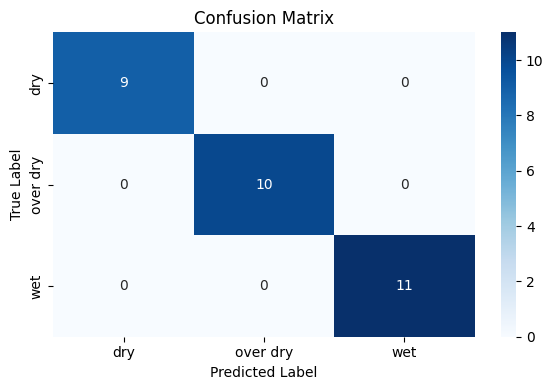

/Users/freshliannes.rosal/anaconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


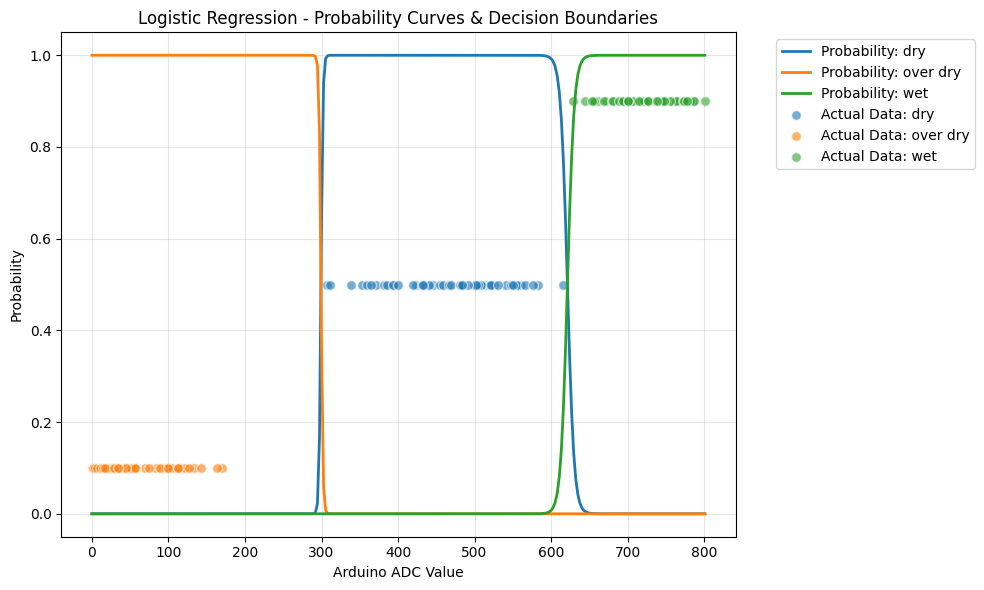

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ==========================================
# 1. LOAD AND CLEAN THE DATA
# ==========================================
df = pd.read_excel('Palay-Raw-Datasets.xlsx', skiprows=7)
df.columns = ['Trial', 'Category', 'Arduino_Value']

# Clean 'Category' and 'Arduino_Value' columns
df['Category'] = df['Category'].str.strip().str.lower().replace({'overdry': 'over dry'})
df['Arduino_Value'] = df['Arduino_Value'].astype(str).str.replace('ADC', '', case=False).str.strip()
df['Arduino_Value'] = pd.to_numeric(df['Arduino_Value'], errors='coerce')
df = df.dropna()

# ==========================================
# 2. TRAIN THE MODEL
# ==========================================
X = df[['Arduino_Value']]
y = df['Category']

# Split Data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Logistic Regression
log_reg = LogisticRegression(solver='lbfgs', random_state=42)
log_reg.fit(X_train, y_train)

# Predict and Evaluate
y_pred = log_reg.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print("==== PERFORMANCE METRICS ====")
print(f"Accuracy: {accuracy * 100:.2f}%\n")
print(classification_report(y_test, y_pred))

# ==========================================
# 3. PRINT COEFFICIENTS & INTERCEPTS
# ==========================================
print("\n==== LOGISTIC REGRESSION EQUATION PARAMETERS ====")
print("Classes Output Order:", log_reg.classes_)
print("Coefficients (Weights):\n", log_reg.coef_)
print("Intercepts (Biases):\n", log_reg.intercept_)

# ==========================================
# 4. VISUALIZATION 1: CONFUSION MATRIX
# ==========================================
cm = confusion_matrix(y_test, y_pred, labels=log_reg.classes_)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=log_reg.classes_, 
            yticklabels=log_reg.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

# ==========================================
# 5. VISUALIZATION 2: PROBABILITY CURVES
# ==========================================
# Generate a sequence of values across the whole range of ADC values
X_range = np.linspace(X.min().values[0], X.max().values[0], 300).reshape(-1, 1)

# Get mathematical probabilities for each class
y_prob = log_reg.predict_proba(X_range)

plt.figure(figsize=(10, 6))

# Plot the probability curve for each class
for i, class_name in enumerate(log_reg.classes_):
    plt.plot(X_range, y_prob[:, i], label=f'Probability: {class_name}', linewidth=2)

# Overlay the actual Data Points (grouped at 0.1, 0.5, 0.9 on the y-axis for visibility)
class_y_map = {'over dry': 0.1, 'dry': 0.5, 'wet': 0.9} 
y_scatter = y.map(class_y_map)

for class_name in log_reg.classes_:
    mask = y == class_name
    plt.scatter(X[mask], y_scatter[mask], alpha=0.6, edgecolors='w', s=50, label=f'Actual Data: {class_name}')

plt.title('Logistic Regression - Probability Curves & Decision Boundaries')
plt.xlabel('Arduino ADC Value')
plt.ylabel('Probability')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

# ==========================================
# 1. LOAD AND CLEAN THE DATA
# ==========================================
df = pd.read_excel('Palay-Raw-Datasets.xlsx', skiprows=7)
df.columns = ['Trial', 'Category', 'Arduino_Value']

# Clean 'Category' and 'Arduino_Value'
df['Category'] = df['Category'].str.strip().str.lower().replace({'overdry': 'over dry'})
df['Arduino_Value'] = df['Arduino_Value'].astype(str).str.replace('ADC', '', case=False).str.strip()
df['Arduino_Value'] = pd.to_numeric(df['Arduino_Value'], errors='coerce')
df = df.dropna()

X = df[['Arduino_Value']]
y = df['Category']

# Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("==== 1. LINEAR SUPPORT VECTOR MACHINE (SVM) ====")
# Train Linear SVM (using linear kernel so it can be easily embedded)
svm_model = SVC(kernel='linear', random_state=42)
svm_model.fit(X_train, y_train)

svm_pred = svm_model.predict(X_test)
print(f"SVM Accuracy: {accuracy_score(y_test, svm_pred) * 100:.2f}%")

print("\nSVM Parameters for Arduino C++:")
print("Classes Output Order:", svm_model.classes_)
# Weights and biases to map to equations
print("Weights (Coef):", svm_model.coef_)
print("Biases (Intercept):", svm_model.intercept_)


print("\n==== 2. GAUSSIAN NAIVE BAYES ====")
# Train Naive Bayes
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

nb_pred = nb_model.predict(X_test)
print(f"Naive Bayes Accuracy: {accuracy_score(y_test, nb_pred) * 100:.2f}%")

print("\nNaive Bayes Parameters for Arduino C++:")
print("Classes Output Order:", nb_model.classes_)
# Means and Variances are all you need to embed this in C++
print("Class Means (Theta):", nb_model.theta_)
print("Class Variances (Var):", nb_model.var_)

==== 1. LINEAR SUPPORT VECTOR MACHINE (SVM) ====
SVM Accuracy: 100.00%

SVM Parameters for Arduino C++:
Classes Output Order: ['dry' 'over dry' 'wet']
Weights (Coef): [[ 0.01459854]
 [-0.15384615]
 [-0.00436681]]
Biases (Intercept): [-3.48175182 95.61538462  1.74235808]

==== 2. GAUSSIAN NAIVE BAYES ====
Naive Bayes Accuracy: 100.00%

Naive Bayes Parameters for Arduino C++:
Classes Output Order: ['dry' 'over dry' 'wet']
Class Means (Theta): [[463.65853659]
 [ 60.9       ]
 [721.79487179]]
Class Variances (Var): [[5573.59079637]
 [2451.04007656]
 [1987.08620411]]


==== 1. LINEAR SUPPORT VECTOR MACHINE (SVM) ====
SVM Accuracy: 100.00%

SVM Parameters for Arduino C++:
Classes Output Order: ['dry' 'over dry' 'wet']
Weights (Coef): [[ 0.01459854]
 [-0.15384615]
 [-0.00436681]]
Biases (Intercept): [-3.48175182 95.61538462  1.74235808]


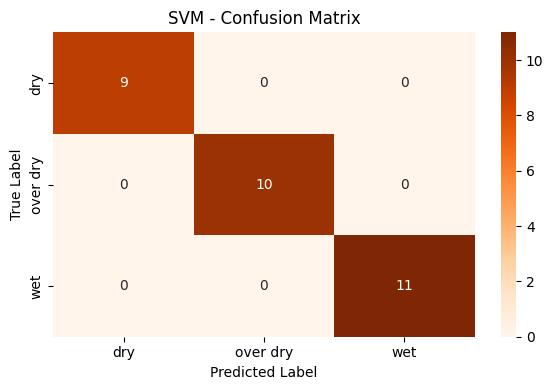

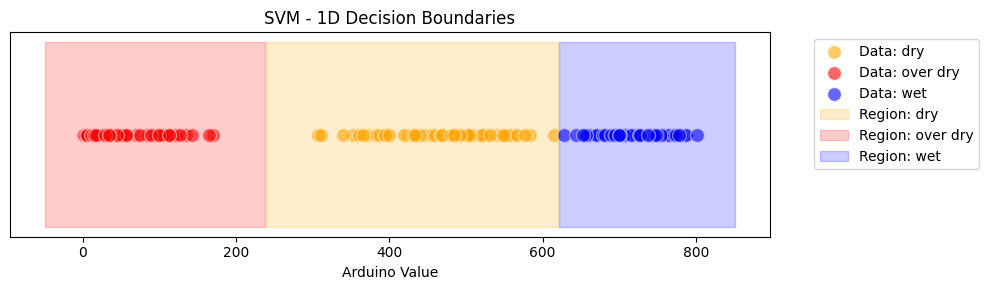


==== 2. GAUSSIAN NAIVE BAYES ====
Naive Bayes Accuracy: 100.00%

Naive Bayes Parameters for Arduino C++:
Classes Output Order: ['dry' 'over dry' 'wet']
Class Means (Theta):
 [[463.65853659]
 [ 60.9       ]
 [721.79487179]]
Class Variances (Var):
 [[5573.59079637]
 [2451.04007656]
 [1987.08620411]]


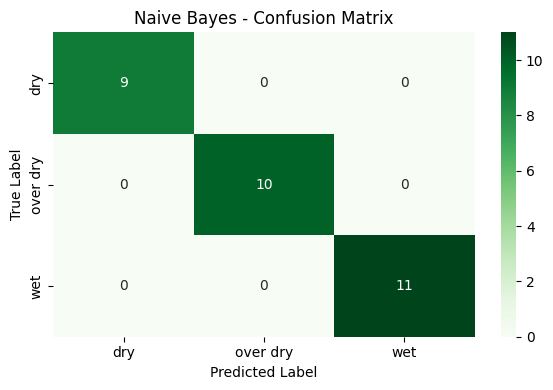

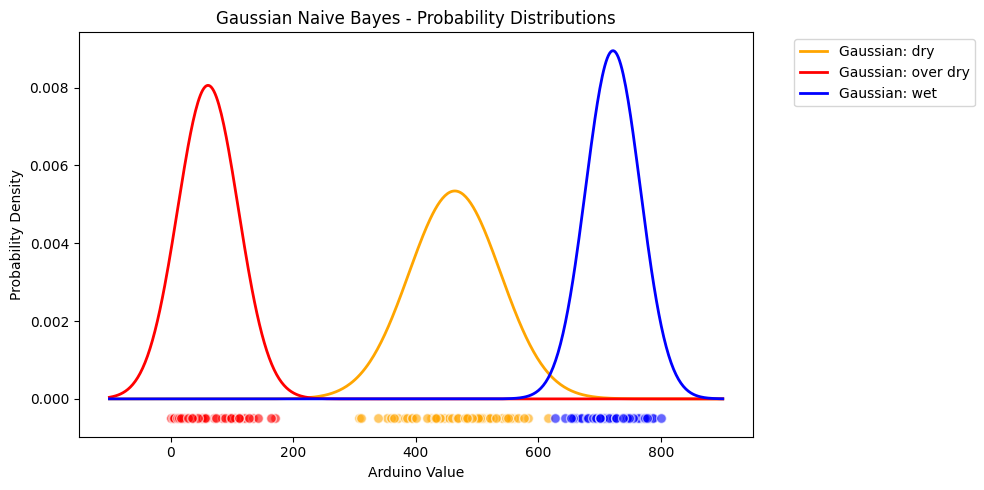

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix

# ==========================================
# 1. LOAD AND CLEAN THE DATA
# ==========================================
df = pd.read_excel('Palay-Raw-Datasets.xlsx', skiprows=7)
df.columns = ['Trial', 'Category', 'Arduino_Value']

# Clean 'Category' and 'Arduino_Value'
df['Category'] = df['Category'].str.strip().str.lower().replace({'overdry': 'over dry'})
df['Arduino_Value'] = df['Arduino_Value'].astype(str).str.replace('ADC', '', case=False).str.strip()
df['Arduino_Value'] = pd.to_numeric(df['Arduino_Value'], errors='coerce')
df = df.dropna()

X = df[['Arduino_Value']]
y = df['Category']

# Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
colors = {'over dry': 'red', 'dry': 'orange', 'wet': 'blue'}

# ==========================================
# 2. LINEAR SUPPORT VECTOR MACHINE (SVM)
# ==========================================
print("==== 1. LINEAR SUPPORT VECTOR MACHINE (SVM) ====")
svm_model = SVC(kernel='linear', random_state=42)
svm_model.fit(X_train, y_train)

svm_pred = svm_model.predict(X_test)
print(f"SVM Accuracy: {accuracy_score(y_test, svm_pred) * 100:.2f}%")

print("\nSVM Parameters for Arduino C++:")
print("Classes Output Order:", svm_model.classes_)
print("Weights (Coef):", svm_model.coef_)
print("Biases (Intercept):", svm_model.intercept_)

# --- SVM Visualizations ---
# Confusion Matrix
cm_svm = confusion_matrix(y_test, svm_pred, labels=svm_model.classes_)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Oranges', xticklabels=svm_model.classes_, yticklabels=svm_model.classes_)
plt.title('SVM - Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

# 1D Decision Regions
X_range = np.linspace(X.min().values[0] - 50, X.max().values[0] + 50, 500).reshape(-1, 1)
svm_regions = svm_model.predict(pd.DataFrame(X_range, columns=['Arduino_Value']))

plt.figure(figsize=(10, 3))
for cls in svm_model.classes_:
    plt.scatter(X[y == cls], [0]*sum(y==cls), color=colors[cls], label=f'Data: {cls}', alpha=0.6, edgecolors='w', s=100)

unique_preds = np.unique(svm_regions)
for cls in unique_preds:
    mask = (svm_regions == cls)
    plt.fill_between(X_range.flatten(), -0.1, 0.1, where=mask, color=colors[cls], alpha=0.2, label=f'Region: {cls}')

plt.yticks([])
plt.xlabel('Arduino Value')
plt.title('SVM - 1D Decision Boundaries')
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(), bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# ==========================================
# 3. GAUSSIAN NAIVE BAYES
# ==========================================
print("\n==== 2. GAUSSIAN NAIVE BAYES ====")
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

nb_pred = nb_model.predict(X_test)
print(f"Naive Bayes Accuracy: {accuracy_score(y_test, nb_pred) * 100:.2f}%")

print("\nNaive Bayes Parameters for Arduino C++:")
print("Classes Output Order:", nb_model.classes_)
print("Class Means (Theta):\n", nb_model.theta_)
print("Class Variances (Var):\n", nb_model.var_)

# --- Naive Bayes Visualizations ---
# Confusion Matrix
cm_nb = confusion_matrix(y_test, nb_pred, labels=nb_model.classes_)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Greens', xticklabels=nb_model.classes_, yticklabels=nb_model.classes_)
plt.title('Naive Bayes - Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

# Gaussian Distribution Curves
plt.figure(figsize=(10, 5))
x_axis = np.linspace(X.min().values[0] - 100, X.max().values[0] + 100, 500)

for i, cls in enumerate(nb_model.classes_):
    mean = nb_model.theta_[i][0]
    var = nb_model.var_[i][0]
    std = np.sqrt(var)
    plt.plot(x_axis, stats.norm.pdf(x_axis, mean, std), label=f'Gaussian: {cls}', color=colors[cls], linewidth=2)
    # Scatter points at the bottom
    plt.scatter(X[y == cls], np.zeros(sum(y==cls)) - 0.0005, color=colors[cls], alpha=0.6, edgecolors='w', s=50)

plt.title('Gaussian Naive Bayes - Probability Distributions')
plt.xlabel('Arduino Value')
plt.ylabel('Probability Density')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()